In [ ]:
!pip -q install keras-facenet mtcnn opencv-python Pillow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.4 MB/s eta 0:00:00


In [ ]:
!pip -q install lz4

Saving Tom 2.png to Tom 2.png
Saving Tom cruise 1.png to Tom cruise 1.png
Image 1: Tom 2.png
Image 2: Tom cruise 1.png


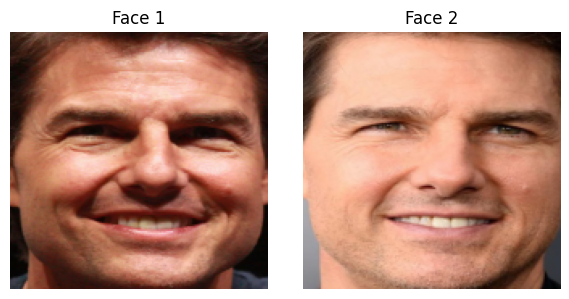

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Embedding distance: 0.6235

Verification result: SAME PERSON ✅
Threshold used: 0.9
Similarity score (0 to 1): 0.307


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2

from mtcnn import MTCNN
from keras_facenet import FaceNet

uploaded = files.upload()
paths = list(uploaded.keys())

if len(paths) < 2:
    raise ValueError("Please upload exactly TWO face images (JPG/PNG).")

img_path_1, img_path_2 = paths[0], paths[1]
print("Image 1:", img_path_1)
print("Image 2:", img_path_2)

detector = MTCNN()

def load_and_crop_face(path, required_size=(160, 160)):
    img = Image.open(path).convert("RGB")
    img = np.asarray(img)

    results = detector.detect_faces(img)
    if len(results) == 0:
        raise ValueError(f"No face detected in {path}. Try a clearer photo.")


    results = sorted(results, key=lambda r: r["box"][2] * r["box"][3], reverse=True)
    x, y, w, h = results[0]["box"]
    x, y = max(0, x), max(0, y)

    face = img[y:y+h, x:x+w]
    face = cv2.resize(face, required_size)
    return face

face1 = load_and_crop_face(img_path_1)
face2 = load_and_crop_face(img_path_2)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(face1); plt.title("Face 1"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(face2); plt.title("Face 2"); plt.axis("off")
plt.tight_layout()
plt.show()

embedder = FaceNet()

def get_embedding(face):
    face = face.astype("float32")
    face = np.expand_dims(face, axis=0)
    emb = embedder.embeddings(face)[0]
    emb = emb / np.linalg.norm(emb)
    return emb

emb1 = get_embedding(face1)
emb2 = get_embedding(face2)

distance = np.linalg.norm(emb1 - emb2)
print("Embedding distance:", round(float(distance), 4))

threshold = 0.9
same_person = distance < threshold

print("\nVerification result:", "SAME PERSON ✅" if same_person else "DIFFERENT PERSON ❌")
print("Threshold used:", threshold)

score = max(0.0, 1.0 - (distance / threshold))
print("Similarity score (0 to 1):", round(float(score), 3))


We asked the user to upload two face images, because verification means comparing one person against another image, not searching a whole database.

We used a face detector (MTCNN) to automatically find where the face is inside each photo and crop only that region, so the background does not confuse the model.

Each detected face is resized to 160 × 160 pixels, which is the input size expected by the pretrained FaceNet network.

We passed both cropped faces through a pretrained CNN, which converts each face into a long numerical vector called an embedding or facial fingerprint.

We normalised those vectors so their scale is consistent, making distance comparisons fair.

We computed the Euclidean distance between the two embeddings, which tells us how similar the faces are in feature space.

We compared that distance to a threshold value, and:

below the threshold means likely the same person,

above the threshold means different people.

Finally, we printed a simple similarity style score and showed both cropped faces so we can visually judge whether the system’s decision makes sense.